<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB
(8523, 11)
(8523,)
(6818, 11)
(1705, 11)
(681

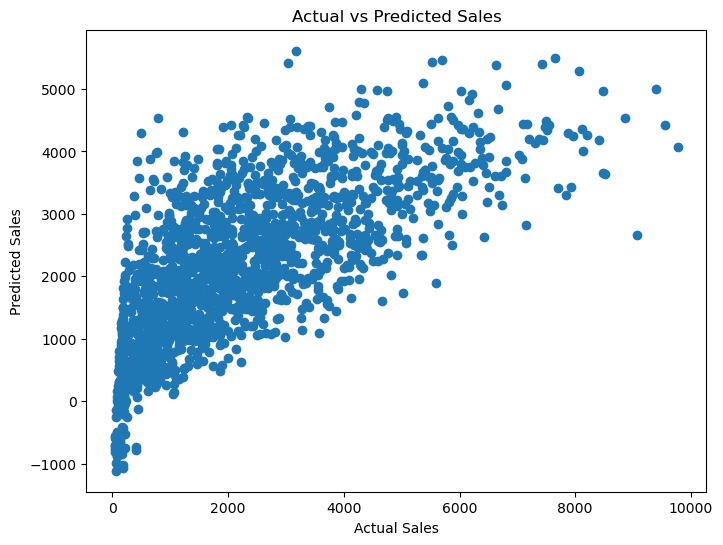

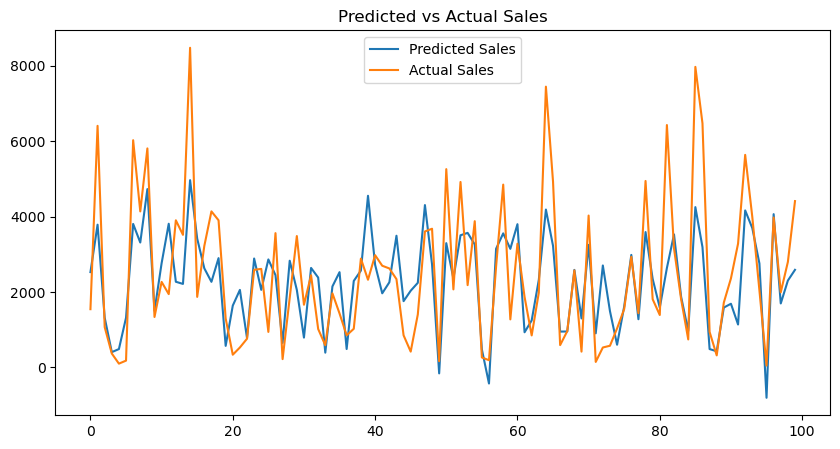

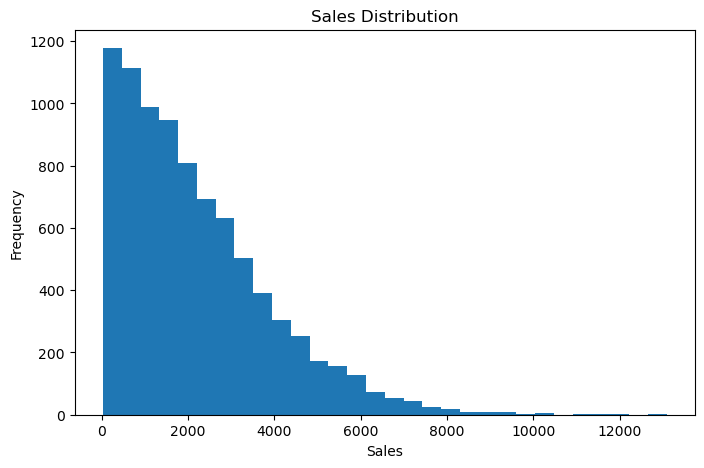

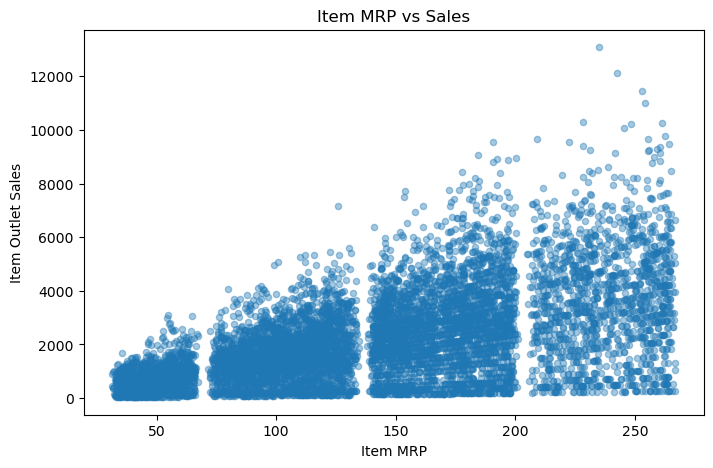

In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("bigmart.csv")

# Display first 5 rows
data.head()

# Check dataset shape
data.shape

# Display dataset information
data.info()

# Check missing values
data.isnull().sum()

# Handle missing values
data['Item_Weight'] = data['Item_Weight'].fillna(data['Item_Weight'].mean())

data['Outlet_Size'] = data['Outlet_Size'].fillna(data['Outlet_Size'].mode()[0])

# Verify missing values again
data.isnull().sum()

# Encoding categorical columns

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    'Item_Identifier',
    'Item_Fat_Content',
    'Item_Type',
    'Outlet_Identifier',
    'Outlet_Size',
    'Outlet_Location_Type',
    'Outlet_Type'
]

for col in categorical_columns:
    data[col] = encoder.fit_transform(data[col])

# Features and target

X = data.drop(columns='Item_Outlet_Sales')

y = data['Item_Outlet_Sales']

print(X.shape)
print(y.shape)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(predictions[:5])

from sklearn.metrics import mean_absolute_error, r2_score
predictions = model.predict(X_test)
print(predictions[:10])
print(y_test[:10])

comparison = pd.DataFrame({
    'Actual Value': y_test[:10],
    'Predicted Value': predictions[:10]
})

print(comparison)

mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)
r2 = r2_score(y_test, predictions)
print("R2 Score:", r2)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(predictions[:100], label='Predicted Sales')
plt.plot(y_test.values[:100], label='Actual Sales')
plt.legend()
plt.title("Predicted vs Actual Sales")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(data['Item_Outlet_Sales'], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))

plt.scatter(
    data['Item_MRP'],
    data['Item_Outlet_Sales'],
    alpha=0.4,
    s=20
)
plt.xlabel("Item MRP")
plt.ylabel("Item Outlet Sales")
plt.title("Item MRP vs Sales")
plt.show()